# Real World Classification

## Load data

Import the necessary libraries

In [ ]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz
# !pip install mlxtend
# import sys
# !{sys.executable} -m pip install mlxtend

  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.8/12.3 MB 18.6 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 54.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.4
    Uninstalling numpy-2.2.4:
      Successfully uninstalled numpy-2.2.4


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [2]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [3]:
miss_cols = df.columns[df.isnull().any()]

for col in miss_cols:
    med = df[col].median()
    std = df[col].std()
    print(f"Column: {col}")
    print(f"Median: {med:.4f}")
    print(f"Standard Deviation: {std:.4f}")
    print("-" * 50)

Column: SepalLengthCm
Median: 6.3000
Standard Deviation: 1.0371
--------------------------------------------------
Column: SepalWidthCm
Median: 2.9000
Standard Deviation: 0.3896
--------------------------------------------------
Column: PetalLengthCm
Median: 5.0856
Standard Deviation: 1.5828
--------------------------------------------------
Column: PetalWidthCm
Median: 1.6000
Standard Deviation: 0.7067
--------------------------------------------------
Column: BranchLength
Median: 16.3000
Standard Deviation: 1.0352
--------------------------------------------------


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputer = KNNImputer(n_neighbors = 2, weights = "uniform")
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [8]:
df.describe()
miss_cols = df.columns[df.isnull().any()]
print(miss_cols)

df.to_csv('data/NYCU_Iris_full.csv')

Index([], dtype='str')


## Data Exploration

SepalWidthMajorAxis      : -0.0968
SepalGlossIndex          : -0.0920
SepalWidthCompactness    : -0.0885
SepalWidthCurvature      : -0.0823
SepalWidthMinorAxis      : -0.0748


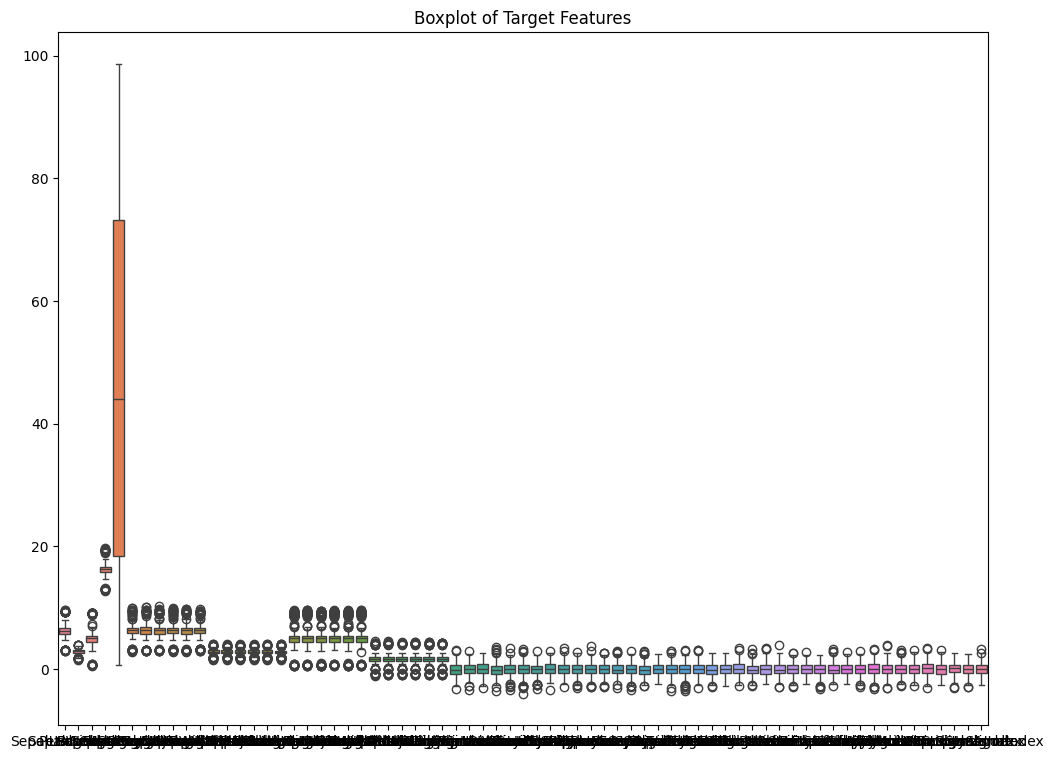

In [13]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration
import seaborn as sns
# sns.histplot(df["PetalWidthCm"])
# plt.title("Histogram of PetalWidthCm")
# plt.show()

target_feature = [c for c in df.columns if c not in ['PetalWidthCm', 'Species', 'Id']]
X = df[target_feature]
y = df["PetalWidthCm"]
r_values = r_regression(X, y)
# for col, r in zip(target_feature, r_values):
#     print(f"{col:25}: {r:.4f}")

# Find largest positive correlation.
# max_idx = np.argmax(r_values)
# max_feature = target_feature[max_idx]
# max_val = r_values[max_idx]
# print(f"{max_feature:25}: {max_val:.4f}")

# Find the top 5 features with the strongest negative correlations.
sorted_indices = np.argsort(r_values)
bottom_five_indices = sorted_indices[:5]
for idx in bottom_five_indices:
    print(f"{target_feature[idx]:25}: {r_values[idx]:.4f}")

# Draw boxplot.
# print(df[target_feature])
plt.figure(figsize=(12, 9))
sns.boxplot(data = df[target_feature])
plt.title("Boxplot of Target Features")
plt.show()

## Model Training

### Prepare the data

In [ ]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.68,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.68,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.60,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.32,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.52,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.6568549188337607, Val loss:0.6694065064199399
100. Training loss: 0.6221502295185728, Val loss:0.6431402541093908
150. Training loss: 0.596378027357279, Val loss:0.62433322003966
200. Training loss: 0.5766146867801114, Val loss:0.6105425302536917
250. Training loss: 0.5610118438370707, Val loss:0.6002260059742968
300. Training loss: 0.548381025060678, Val loss:0.59238649843664
350. Training loss: 0.5379370518835056, Val loss:0.5863597573819553
400. Training loss: 0.5291456861134621, Val loss:0.5816899477823353
450. Training loss: 0.5216329209419487, Val loss:0.5780555737549651
500. Training loss: 0.5151299358063228, Val loss:0.5752242862737781
550. Training loss: 0.5094388541514174, Val loss:0.5730245279996954
600. Training loss: 0.5044108781325769, Val loss:0.5713272384988431
650. Training loss: 0.4999319649657823, Val loss:0.5700337341719391
700. Training loss: 0.4959132136848251, Val loss:0.5690674802121839
750. Training loss: 0.4922842659760617, Val loss:0.5683

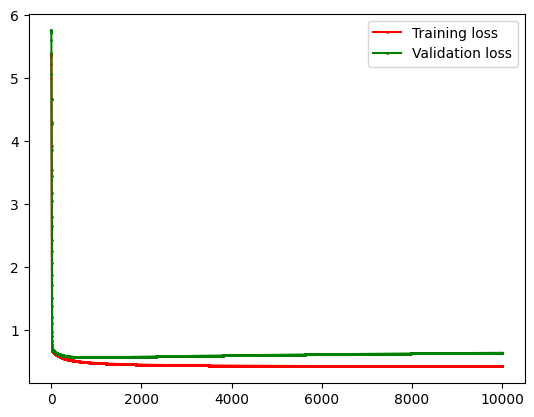

Model parameters (weights): [[-3.16671405]
 [ 0.96378652]
 [ 0.83990167]
 [-0.4180837 ]
 [ 1.74502879]
 [ 0.62487423]
 [ 0.29958784]
 [-0.22838562]
 [ 0.60870425]
 [ 1.36313397]
 [ 1.12790621]
 [ 0.14893735]
 [ 0.92454585]
 [-0.27283276]
 [-1.06963864]
 [ 0.01162295]
 [ 1.27790483]
 [ 0.44132451]
 [ 0.68553709]
 [-0.43826338]
 [ 0.9673365 ]
 [ 0.84148196]
 [-0.3468579 ]
 [ 0.90486718]
 [-0.31474647]
 [ 1.847194  ]
 [ 1.64005405]
 [ 1.40391656]
 [ 1.92168179]
 [ 1.99424719]
 [ 1.39606947]
 [-2.27783136]
 [ 1.55587208]
 [-0.35172483]
 [ 0.19436139]
 [-1.47474124]
 [ 0.70341727]
 [-1.03992665]
 [-2.9589842 ]
 [-0.43548447]
 [-1.25497251]
 [-0.42453951]
 [-0.99625378]
 [-1.23028094]
 [ 0.50217225]
 [-0.05280497]
 [ 0.00484368]
 [ 0.31803145]
 [-0.67676747]
 [-0.65165426]
 [-0.47959356]
 [ 0.34596395]
 [ 0.18234757]
 [-0.63288266]
 [-0.37222655]
 [ 0.51603202]
 [-0.86544796]
 [-1.26660336]
 [-0.28969116]
 [ 0.59267864]
 [-1.02319268]
 [ 0.72941854]
 [ 0.60718625]
 [-1.54943383]
 [ 0.0940992

In [16]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='', reg_lambda=0.0)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


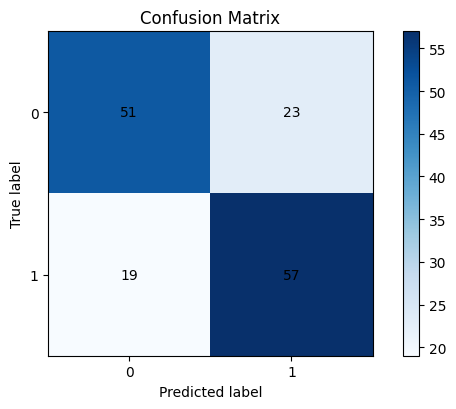

{'Accuracy': 0.72,
 'Precision': 0.7125,
 'Recall': 0.75,
 'F1-score': 0.7307692307692307}

In [17]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)

## K-fold Cross-Validation

In [ ]:
df_full = pd.read_csv('data/NYCU_Iris_full.csv')
X = df[feature_cols].values.astype(float)
y = df['Species'].values


In [51]:
from sklearn.model_selection import KFold, cross_val_score

learning_rates = [0.005, 0.01, 0.1, 0.5]
regul_params = [1.0, 2.0, 4.0, 8.0]
results = []

kf = KFold(n_splits = 5, shuffle = True, random_state = seed)

for lr in learning_rates:
    row_results = []
    for reg_l in regul_params:
        np.random.seed(seed)
        model = LinearModel(dim = X.shape[1], 
                               lr = lr, 
                               reg_type = 'l2', 
                               reg_lambda = reg_l,
                               loss_fn = loss_fn, 
                               act_fn = act_fn, 
                               grad_fn = grad_fn,
                               verbose = False,
                               plot_curve = False)
        
        scores = cross_val_score(model, X, y, cv = kf, scoring = 'accuracy')
        row_results.append(scores.mean())
        
    results.append(row_results)

In [56]:
df_table = pd.DataFrame(results, index = learning_rates, columns = regul_params)
print(df_table)

         1.0    2.0    4.0    8.0
0.005  0.520  0.520  0.520  0.520
0.010  0.520  0.520  0.520  0.520
0.100  0.628  0.630  0.624  0.622
0.500  0.556  0.542  0.508  0.482


learning rate: 0.1, regularization parameter: 2.0
Model Evaluation
Accuracy  : 0.7533
Precision : 0.7294
Recall    : 0.8158
F1-score  : 0.7702


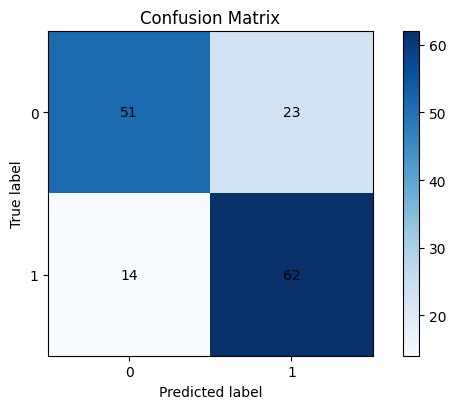

learning rate: 0.1, regularization parameter: 1.0
Model Evaluation
Accuracy  : 0.7400
Precision : 0.7342
Recall    : 0.7632
F1-score  : 0.7484


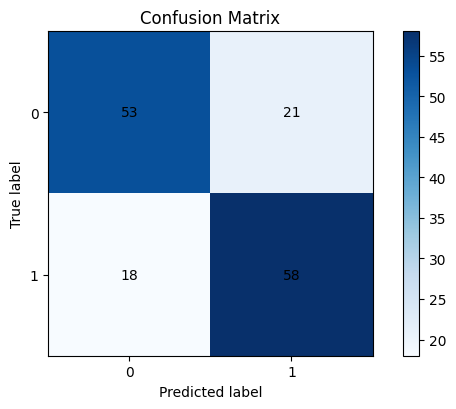

In [60]:
best_params = [(0.1, 2.0), (0.1, 1.0)]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = seed)

for lr, reg_l in best_params:
    print(f"learning rate: {lr}, regularization parameter: {reg_l}")
    np.random.seed(seed)
    model = LinearModel(dim = X_train.shape[1], 
                               lr = lr, 
                               reg_type = 'l2', 
                               reg_lambda = reg_l,
                               loss_fn = loss_fn, 
                               act_fn = act_fn, 
                               grad_fn = grad_fn,
                               verbose = False,
                               plot_curve = False)
    model.fit(X_train, y_train, n_iteration = 10000)
    y_pred = model.predict(X_test)
    evaluate_binary_classifier(y_test, y_pred)

# Assignment 2

## 2. SVM

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

df = pd.read_csv('mobile_price.csv')
X = df.drop('price_range', axis=1)
y = df['price_range']

seed = 42
np.random.seed(seed)

# Split 1st time.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=seed)

# Split 2nd time.
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 1200, Val: 400, Test: 400


In [91]:
svm_base = SVC(C = 1.0)
svm_base.fit(X_train, y_train)

def report_score_base(model, X, y, name):
    np.random.seed(seed)
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average = 'weighted')
    print(f"{name} - Accuracy: {acc:.4f}, F1-score: {f1:.4f}")

report_score_base(svm_base, X_train, y_train, "Training")
report_score_base(svm_base, X_val, y_val, "Validation")
report_score_base(svm_base, X_test, y_test, "Testing")

Training - Accuracy: 0.9450, F1-score: 0.9445
Validation - Accuracy: 0.9450, F1-score: 0.9448
Testing - Accuracy: 0.9575, F1-score: 0.9573


In [92]:
regul_params = [0.001, 0.01, 0.1, 1.0, 10, 100, 1000, 10000]

train_accs = []
val_accs = []
test_accs = []
train_f1s = []
val_f1s = []
test_f1s = []

for reg_l in regul_params:
    svm = SVC(C = reg_l)
    svm.fit(X_train, y_train)
    y_train_pred = svm.predict(X_train)
    y_val_pred = svm.predict(X_val)
    y_test_pred = svm.predict(X_test)
    
    train_accs.append(accuracy_score(y_train, y_train_pred))
    val_accs.append(accuracy_score(y_val, y_val_pred))
    test_accs.append(accuracy_score(y_test, y_test_pred))
    
    train_f1s.append(f1_score(y_train, y_train_pred, average='weighted'))
    val_f1s.append(f1_score(y_val, y_val_pred, average='weighted'))
    test_f1s.append(f1_score(y_test, y_test_pred, average='weighted'))

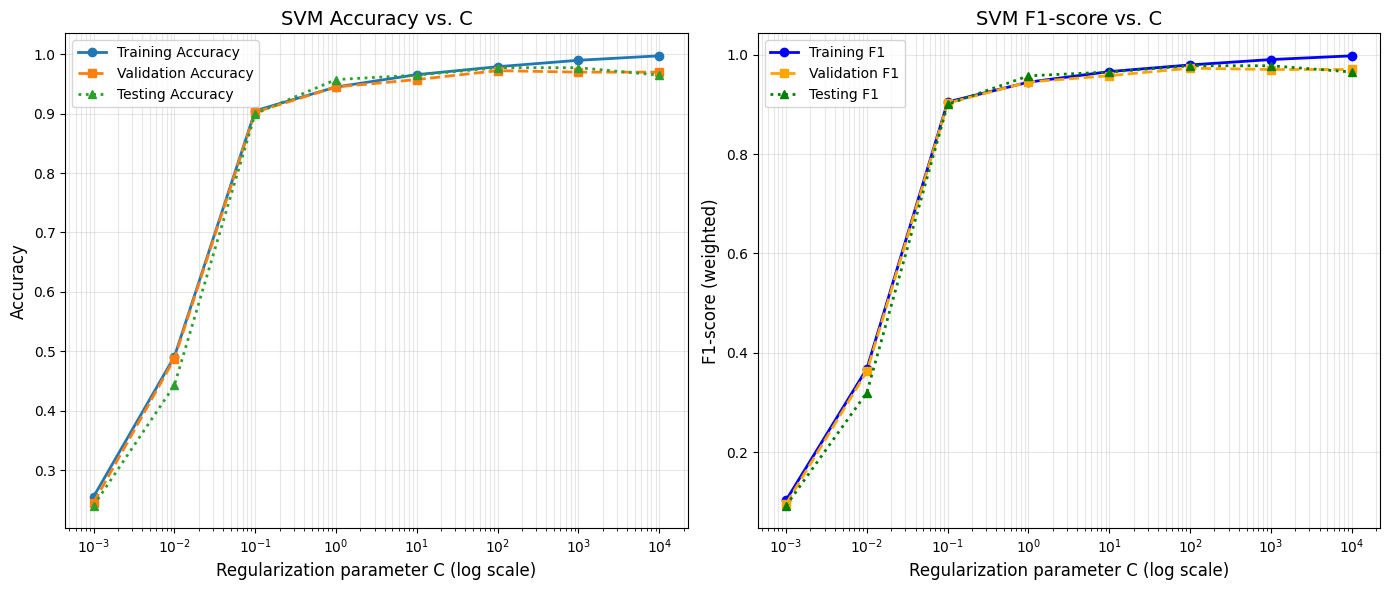

In [93]:
# Plot

plt.figure(figsize=(14, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(regul_params, train_accs, label='Training Accuracy', marker='o', linestyle='-', linewidth=2)
plt.plot(regul_params, val_accs, label='Validation Accuracy', marker='s', linestyle='--', linewidth=2)
plt.plot(regul_params, test_accs, label='Testing Accuracy', marker='^', linestyle=':', linewidth=2)

plt.xscale('log')
plt.xlabel('Regularization parameter C (log scale)', fontsize = 12)
plt.ylabel('Accuracy', fontsize = 12)
plt.title('SVM Accuracy vs. C', fontsize = 14)
plt.legend()
plt.grid(True, which = "both", ls = "-", alpha = 0.3)

# F1-score
plt.subplot(1, 2, 2)
plt.plot(regul_params, train_f1s, label='Training F1', marker='o', linestyle='-', linewidth=2, color='blue')
plt.plot(regul_params, val_f1s, label='Validation F1', marker='s', linestyle='--', linewidth=2, color='orange')
plt.plot(regul_params, test_f1s, label='Testing F1', marker='^', linestyle=':', linewidth=2, color='green')

plt.xscale('log')
plt.xlabel('Regularization parameter C (log scale)', fontsize = 12)
plt.ylabel('F1-score (weighted)', fontsize = 12)
plt.title('SVM F1-score vs. C', fontsize = 14)
plt.legend()
plt.grid(True, which = "both", ls = "-", alpha = 0.3)

plt.tight_layout()
plt.show()

## 3. Association Rule Mining

In [13]:
df_target = df[df["price_range"] == 1].copy()
features = ["ram", "int_memory", "px_width", "battery_power"]

def categorize(series, name):
    f_min = series.min()
    f_max = series.max()
    f_range = f_max - f_min
    
    low_bound = f_min + f_range * 0.3
    high_bound = f_min + f_range * 0.7
    
    def get_label(val):
        if val <= low_bound:
            return f"{name}_low"
        elif val <= high_bound:
            return f"{name}_medium"
        else:
            return f"{name}_high"
    
    return series.apply(get_label)

transactions_df = pd.DataFrame()
for f in features:
    transactions_df[f] = categorize(df_target[f], f)

# print(transactions_df)
transactions = transactions_df.values.tolist()

In [20]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_onehot = pd.DataFrame(te_ary, columns = te.columns_)

frequent_itemsets = fpgrowth(df_onehot, min_support = 0.3, use_colnames = True)
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).reset_index(drop=True)
print(frequent_itemsets)

   support                                       itemsets
0    0.682                        frozenset({ram_medium})
1    0.416                   frozenset({px_width_medium})
2    0.414              frozenset({battery_power_medium})
3    0.412                 frozenset({int_memory_medium})
4    0.318  frozenset({ram_medium, battery_power_medium})
5    0.316                    frozenset({int_memory_low})
6    0.308                 frozenset({battery_power_low})
7    0.306       frozenset({ram_medium, px_width_medium})


In [ ]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric = "confidence", min_threshold = 0.4)

filtered_rules = rules[rules['lift'] >= 0.8]
# print(filtered_rules)

target_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
final_rules = filtered_rules[target_cols].sort_values(by = 'lift', ascending = False)

print(final_rules)

                         antecedents                        consequents  \
0            frozenset({ram_medium})  frozenset({battery_power_medium})   
1  frozenset({battery_power_medium})            frozenset({ram_medium})   
2            frozenset({ram_medium})       frozenset({px_width_medium})   
3       frozenset({px_width_medium})            frozenset({ram_medium})   

   antecedent support  consequent support  support  confidence      lift  \
0               0.682               0.414    0.318    0.466276  1.126270   
1               0.414               0.682    0.318    0.768116  1.126270   
2               0.682               0.416    0.306    0.448680  1.078559   
3               0.416               0.682    0.306    0.735577  1.078559   

   representativity  leverage  conviction  zhangs_metric   jaccard  certainty  \
0               1.0  0.035652    1.097945       0.352557  0.408740   0.089208   
1               1.0  0.035652    1.371375       0.191319  0.408740   0.270805   
